# What's Actually Driving Peninsular Malaysia's Grid Emission Factor?

## The Question

Notebook 01 found that Peninsular Malaysia's grid emission factor barely moved between 2017 and 2024. Is that because the fuel mix behind it barely moved, or did something more interesting happen underneath a flat headline number? And separately: how does this compare to what Malaysia has publicly committed to on the renewable energy transition?

## The Answer

The fuel mix didn't stay still; it just didn't move in the decarbonizing direction. Coal's share of Peninsular Malaysia's generation fuel mix was 63.9% in 2017 and 67.9% in 2024, having ranged as high as 74.2% (2020) in between; natural gas's share fell from 35.7% to 32.0% over the same window. There is no year in this series where coal's share drops below its 2017 starting point. Malaysia's National Energy Transition Roadmap (NETR) targets 31% renewable *installed capacity* share by 2025, but that is a capacity target, not a generation or emission-factor target, and this analysis has no generation-level renewable energy data to check progress against it directly (see caveats). What the fuel-mix data can say is narrower and more concrete: whatever renewable capacity exists, it has not been enough to reduce coal's share of what actually gets burned to generate Peninsular Malaysia's electricity.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

fuel_mix = pd.read_csv('../data/processed/fuel_mix_peninsular.csv')
netr = pd.read_csv('../data/processed/netr_re_capacity_targets.csv')
fuel_mix.head()

,year,fuel_type,fuel_consumption_tj,ghg_emission_gg_co2e,net_electricity_generation_gwh
0,2017,Coal,731160,70116,121844
1,2017,Natural Gas,408814,22957,121844
2,2017,Diesel,1673,124,121844
3,2017,Fuel Oil,2632,204,121844
4,2018,Coal,801453,76887,123902


In [2]:
# House chart style v2: MBB-style chart conventions:
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, exhibit style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Coal and gas share of the fuel mix, year by year

In [3]:
shares = []
for year, group in fuel_mix.groupby('year'):
    total = group['fuel_consumption_tj'].sum()
    coal_share = group.loc[group['fuel_type'] == 'Coal', 'fuel_consumption_tj'].values[0] / total * 100
    gas_share = group.loc[group['fuel_type'] == 'Natural Gas', 'fuel_consumption_tj'].values[0] / total * 100
    shares.append({'year': year, 'coal_share_pct': round(coal_share, 1), 'gas_share_pct': round(gas_share, 1)})

shares_df = pd.DataFrame(shares).set_index('year')
shares_df

,coal_share_pct,gas_share_pct
year,,
2017,63.9,35.7
2018,67.3,32.5
2019,61.3,37.5
2020,74.2,25.7
2021,71.3,28.5
2022,66.6,32.8
2023,68.2,31.7
2024,67.9,32.0


## Visualizing the fuel mix shift

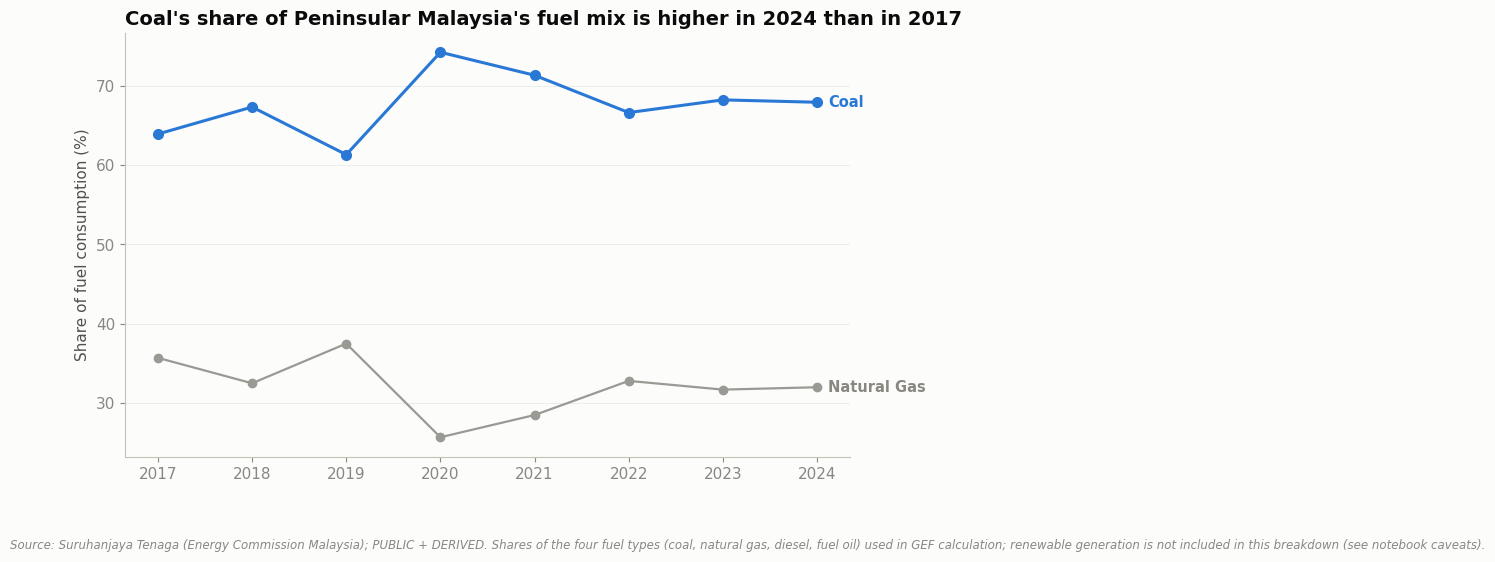

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(shares_df.index, shares_df['coal_share_pct'], marker='o', markersize=7,
        linewidth=2.2, color=ACCENT_1, zorder=3)
ax.plot(shares_df.index, shares_df['gas_share_pct'], marker='o', markersize=6,
        linewidth=1.6, color=GRAY, zorder=2)

end_label(ax, shares_df.index[-1], shares_df['coal_share_pct'].iloc[-1], 'Coal', ACCENT_1, weight='bold')
end_label(ax, shares_df.index[-1], shares_df['gas_share_pct'].iloc[-1], 'Natural Gas', INK_MUTED)

ax.set_title("Coal's share of Peninsular Malaysia's fuel mix is higher in 2024 than in 2017", loc='left')
ax.set_ylabel('Share of fuel consumption (%)')
ax.set_xlabel('')
fig.subplots_adjust(right=0.85)

add_source(ax.figure, 'Source: Suruhanjaya Tenaga (Energy Commission Malaysia); PUBLIC + DERIVED. Shares of the four '
                       'fuel types (coal, natural gas, diesel, fuel oil) used in GEF calculation; renewable '
                       'generation is not included in this breakdown (see notebook caveats).')
plt.show()


## How does this compare to Malaysia's renewable energy targets?

Malaysia's National Energy Transition Roadmap (NETR) commits to a 31% renewable energy *installed capacity* share by 2025, rising to 40% by 2035 and 70% by 2050.

In [5]:
netr

,target_year,re_installed_capacity_share_pct,source
0,2025,31,"National Energy Transition Roadmap (NETR), Gov..."
1,2035,40,"National Energy Transition Roadmap (NETR), Gov..."
2,2050,70,"National Energy Transition Roadmap (NETR), Gov..."


This analysis **cannot check progress against that target directly**, for a reason worth stating plainly rather than glossing over: the NETR target is a capacity-mix figure (what generation capacity exists), while the fuel-mix data above is a generation/consumption-mix figure (what actually got burned); two different metrics that a renewable capacity build-out does not automatically convert between one-for-one (a solar plant can exist and still contribute a small share of actual generation relative to its capacity, due to intermittency). What can be said without conflating the two: whatever renewable capacity has come online through 2024, it has not been enough to reduce coal's share of Peninsular Malaysia's actual generation fuel mix below its 2017 level.

## Strategic Recommendation

- **A business benchmarking its Malaysia-based Scope 2 emissions should not treat NETR's capacity targets as evidence of near-term generation-mix improvement.** Capacity announcements and actual fuel-mix outcomes have diverged over this study window; a capacity target being on schedule (which this analysis cannot itself verify) would not on its own guarantee the grid actually burns less coal.
- **The most defensible planning assumption, based on the last seven years, is "the grid's carbon intensity is roughly flat," not "the grid is decarbonizing."** Businesses with firm Scope 2 reduction targets on a 2025–2030 timeline should weight independent action (PPAs, on-site renewables) accordingly, rather than building in an assumed grid-driven improvement that the fuel-mix record does not support.

## Confidence & Caveats

- **No renewable generation time series is available in this dataset.** The source GEF calculation explicitly excludes "Total RE" from its Main-Activity-Producer fuel accounting (see `DATA_DICTIONARY.md`). This notebook can describe the coal/gas mix shift precisely; it cannot state Malaysia's actual renewable *generation* share for any year in this window, only its *capacity* target.
- **Diesel and fuel oil are excluded from the two-line chart above** for readability, both are consistently under 1% of the fuel mix across all years and do not change the coal/gas story.
- **This is Peninsular Malaysia only.** Sabah and Sarawak's fuel-level breakdowns are not published in the same source documents, so this mechanism-level analysis cannot be extended to explain their GEF trends from notebook 01.
- **Descriptive, not causal.** This notebook shows what the fuel mix did; it does not explain policy-level *why* (e.g., specific plant retirements, demand growth outpacing renewable build-out, LNG pricing); that would require a different, more qualitative dataset.

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context on the mechanism behind this notebook's coal-share finding; kept separate from the PUBLIC/DERIVED Suruhanjaya Tenaga figures above. Full citations in [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md).*

Coal's rising share isn't a policy reversal; it's renewable deployment consistently lagging demand growth and its own targets. Malaysia's National Energy Transition Roadmap (NETR) targets 70% renewable energy by 2050 and a full coal phase-out by 2045, but several structural constraints have slowed the buildout: land and grid-connection access are scarce and contested with agriculture and industry, integrating large amounts of intermittent solar risks grid stability without matching storage and grid upgrades, and project approvals have faced regulatory and land-acquisition delays. At the same time, electricity demand keeps climbing, and gas and coal remain the only sources that can reliably cover that baseload today. The government has stated no new coal plants will be built, but retiring the existing fleet on schedule is a separate, harder problem from not building new ones, which is exactly what this notebook's fuel-mix data shows hasn't happened yet.

**Sources:** [TransitionZero, "From tenaga to tindakan: sparking Malaysia's coal-to-clean transition"](https://www.transitionzero.org/insights/tz-cat-malaysias-coal-to-clean-transition); [Ember, "Solar and grid flexibility critical for Malaysia's future electricity affordability and security"](https://ember-energy.org/latest-insights/solar-and-grid-flexibility-critical-for-malaysia/).